# RiMEA 14: Route Choice

This notebook compares two route-choice modes based on the exported [`scenarios/Rimea-14.zip`](scenarios/Rimea-14.zip) setup:

- **No stages**: agents use the short route directly to the exit.
- **With stages**: the scenario keeps the encoded checkpoints and transitions, which makes the route choice configurable and results in a mixed split between the short and long route.

The goal here is not to prove a unique answer, but to document the current behavior as one of the RiMEA outcomes: `short` or `configurable/mixed`.

In [1]:
import io
import json
import tempfile
import zipfile
from contextlib import redirect_stdout
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from core.scenario import load_scenario, run_scenario


In [2]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8fafc",
        "axes.edgecolor": "#334155",
        "axes.labelcolor": "#0f172a",
        "axes.titleweight": "bold",
        "xtick.color": "#0f172a",
        "ytick.color": "#0f172a",
        "font.size": 11,
    }
)

SCENARIO_ZIP = Path("scenarios") / "Rimea-14.zip"
COLORS = {"staged": "#2563EB", "direct": "#D97706"}


## Load the Exported Scenario

The exported RiMEA 14 archive already contains the staged route. For a stable notebook run, we keep the geometry and route logic but switch the source to a 30-agent batch instead of the original small-area flow spawn.

In [3]:
with zipfile.ZipFile(SCENARIO_ZIP) as archive:
    raw = json.loads(archive.read("config.json"))
    geometry_wkt = archive.read("geometry.wkt").decode()

raw["distributions"]["jps-distributions_0"]["parameters"].update(
    {
        "use_flow_spawning": False,
        "distribution_mode": "by_number",
        "number": 30,
    }
)

upper_checkpoint = Polygon(raw["checkpoints"]["jps-checkpoints_1"]["coordinates"])
upper_checkpoint_2 = Polygon(raw["checkpoints"]["jps-checkpoints_2"]["coordinates"])
exit_polygon = Polygon(raw["exits"]["jps-exits_0"]["coordinates"])

print(f"Journeys in export: {raw['journeys']}")
print(f"Transitions in export: {raw['transitions']}")


Journeys in export: [{'id': 'journey_0', 'stages': ['jps-distributions_0', 'jps-checkpoints_0', 'jps-checkpoints_1', 'jps-checkpoints_2', 'jps-exits_0'], 'transitions': [{'from': 'jps-distributions_0', 'to': 'jps-checkpoints_0', 'journey_id': 'journey_0'}, {'from': 'jps-checkpoints_0', 'to': 'jps-exits_0', 'journey_id': 'journey_0'}, {'from': 'jps-checkpoints_0', 'to': 'jps-checkpoints_1', 'journey_id': 'journey_0'}, {'from': 'jps-checkpoints_1', 'to': 'jps-checkpoints_2', 'journey_id': 'journey_0'}, {'from': 'jps-checkpoints_2', 'to': 'jps-exits_0', 'journey_id': 'journey_0'}]}]
Transitions in export: [{'from': 'jps-distributions_0', 'to': 'jps-checkpoints_0', 'journey_id': 'journey_0'}, {'from': 'jps-checkpoints_0', 'to': 'jps-exits_0', 'journey_id': 'journey_0'}, {'from': 'jps-checkpoints_0', 'to': 'jps-checkpoints_1', 'journey_id': 'journey_0'}, {'from': 'jps-checkpoints_1', 'to': 'jps-checkpoints_2', 'journey_id': 'journey_0'}, {'from': 'jps-checkpoints_2', 'to': 'jps-exits_0', 'j

## Helper Functions

In [4]:
def run_variant(config: dict, name: str):
    tmpdir = tempfile.TemporaryDirectory()
    scenario_dir = Path(tmpdir.name)
    (scenario_dir / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")
    (scenario_dir / "geometry.wkt").write_text(geometry_wkt, encoding="utf-8")

    scenario = load_scenario(str(scenario_dir))
    with redirect_stdout(io.StringIO()):
        result = run_scenario(scenario, seed=42)

    traj_df = result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy()
    traj = pedpy.TrajectoryData(traj_df, frame_rate=result.frame_rate)
    return {
        "name": name,
        "scenario": scenario,
        "result": result,
        "trajectory": traj,
        "walkable_area": pedpy.WalkableArea(scenario.walkable_polygon),
        "tmpdir": tmpdir,
    }


def classify_routes(traj):
    rows = []
    for agent_id, agent_df in traj.data.groupby("id"):
        points = [Point(x, y) for x, y in zip(agent_df["x"], agent_df["y"])]
        uses_long_route = any(upper_checkpoint.covers(point) for point in points) and any(
            upper_checkpoint_2.covers(point) for point in points
        )
        rows.append({"id": int(agent_id), "route": "long" if uses_long_route else "short"})
    return pd.DataFrame(rows)


In [5]:
%%capture
staged = run_variant(json.loads(json.dumps(raw)), "with stages")

direct_raw = json.loads(json.dumps(raw))
direct_raw["journeys"] = [{"id": "journey_0", "stages": ["jps-distributions_0", "jps-exits_0"]}]
direct_raw["transitions"] = []
direct = run_variant(direct_raw, "no stages")


In [6]:
staged_routes = classify_routes(staged["trajectory"])
direct_routes = classify_routes(direct["trajectory"])

summary = pd.DataFrame(
    [
        {
            "mode": "with stages",
            "evacuation_time [s]": staged["result"].evacuation_time,
            "agents": staged["trajectory"].data["id"].nunique(),
            "short route": int((staged_routes["route"] == "short").sum()),
            "long route": int((staged_routes["route"] == "long").sum()),
            "classification": "mixed / configurable",
        },
        {
            "mode": "no stages",
            "evacuation_time [s]": direct["result"].evacuation_time,
            "agents": direct["trajectory"].data["id"].nunique(),
            "short route": int((direct_routes["route"] == "short").sum()),
            "long route": int((direct_routes["route"] == "long").sum()),
            "classification": "short",
        },
    ]
)
summary


,mode,evacuation_time [s],agents,short route,long route,classification
0,with stages,157.34,30,19,11,mixed / configurable
1,no stages,88.92,30,30,0,short


## Geometry and Trajectories

The staged mode sends part of the crowd through the upper route, while the direct mode collapses to the shorter same-floor path.

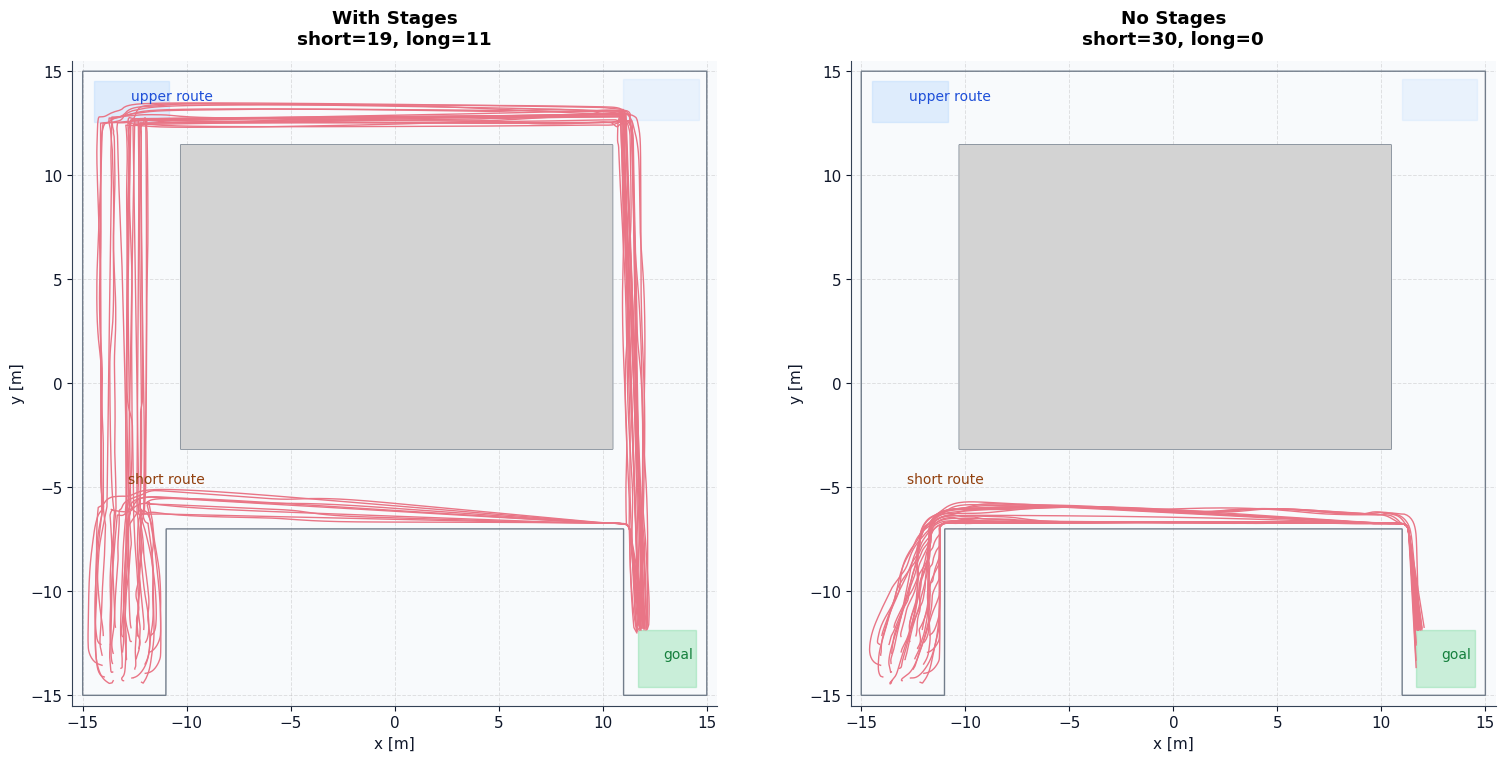

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 7.5), constrained_layout=True)

for ax, run, route_df in [
    (axes[0], staged, staged_routes),
    (axes[1], direct, direct_routes),
]:
    pedpy.plot_trajectories(
        traj=run["trajectory"],
        walkable_area=run["walkable_area"],
        axes=ax,
        alpha=0.18,
        linewidth=0.35,
        color=COLORS["staged" if run['name'] == 'with stages' else 'direct'],
    ).set_aspect("equal")
    ax.fill(*zip(*raw["checkpoints"]["jps-checkpoints_1"]["coordinates"]), color="#93C5FD", alpha=0.25)
    ax.fill(*zip(*raw["checkpoints"]["jps-checkpoints_2"]["coordinates"]), color="#BFDBFE", alpha=0.25)
    ax.fill(*zip(*raw["exits"]["jps-exits_0"]["coordinates"]), color="#22C55E", alpha=0.22)
    ax.text(-12.7, 13.6, "upper route", fontsize=10, color="#1D4ED8")
    ax.text(-12.8, -4.8, "short route", fontsize=10, color="#92400E")
    ax.text(12.9, -13.2, "goal", fontsize=10, color="#15803D")
    ax.set_title(
        f"{run['name'].title()}\n"
        f"short={int((route_df['route'] == 'short').sum())}, long={int((route_df['route'] == 'long').sum())}",
        pad=12,
    )
    ax.set_xlim(-15.5, 15.5)
    ax.set_ylim(-15.5, 15.5)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()


## Route Split Comparison

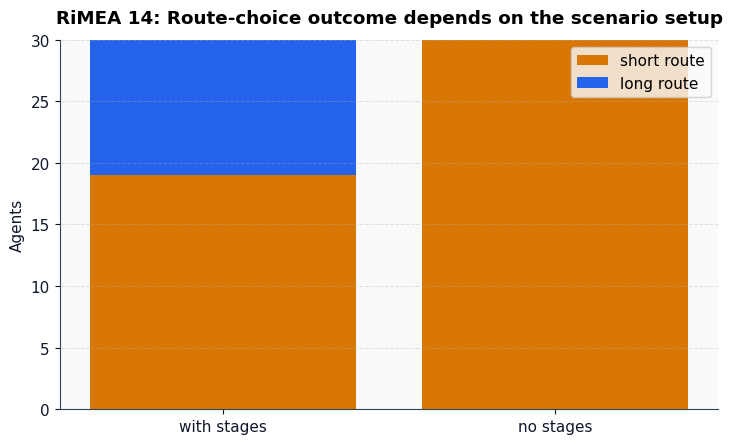

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = [0, 1]
short_counts = [int((staged_routes['route'] == 'short').sum()), int((direct_routes['route'] == 'short').sum())]
long_counts = [int((staged_routes['route'] == 'long').sum()), int((direct_routes['route'] == 'long').sum())]
ax.bar(x, short_counts, color="#D97706", label="short route")
ax.bar(x, long_counts, bottom=short_counts, color="#2563EB", label="long route")
ax.set_xticks(x, ["with stages", "no stages"])
ax.set_ylabel("Agents")
ax.set_title("RiMEA 14: Route-choice outcome depends on the scenario setup", pad=12)
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.show()


In [9]:
for run in [staged, direct]:
    run["result"].cleanup()
    run["tmpdir"].cleanup()
